# init

In [1]:
PDF_export_active = False

In [1]:
import sled_ROI_tools
import sled_general_tools
import sled_stat_tools
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os
import sys
import jsimg as jsi
import ttracking as tt
import js_manuscript as jsm
import copy
import glob
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from scipy.stats import ttest_ind
from matplotlib import animation
from matplotlib.animation import FuncAnimation
import statsmodels.api as sm
import matplotlib as mpl
from scipy import stats
import importlib
import time
from sklearn.linear_model import LinearRegression
import seaborn as sns
import sled_general_tools
import sled_ROI_tools
from contextlib import nullcontext

In [2]:
trialStart = 0.15
sampleEnd = trialStart+1.2
delayEnd = sampleEnd+1.25
figSaveDir = "/export/general/pooledData/Calcium/JS_figsPanels/Fig4"

mdDir = '/home/range6-raid3/scheij/Documents/Data/mainDS'
mdTitle = 'allSlim3'
masterData = pickle.load(open(fr'{mdDir}/{mdTitle}.p', 'rb'))
anms = list(masterData.keys())
anatKeys = ['dendrites', 'somas']
frs = [44.6, 22.8]

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['pdf.fonttype'] = 42

In [3]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'##'consensus_NMFtc_dff_bc_decon_sp'#'consensus_NMFtc_dff_bc'
factors = [10,5]
#Z = 'standard_noise'
Z = 'std_only'
phases2 = ['pre', 'preShift_early', 'preShift_late', 'post', 'late', 'day-1_beg', 'day-1_mid', 'day-1_end', 'shiftDay_post', 'shiftDay_pre', 'early'] 
dffKeys = ['consensus_NMFtc_dff_bc_decon_sp_events']
windowSize = [-3.6,3.6]
importlib.reload(jsm)
allAnmParams = jsm.get_allAnmParams(masterData, anms, frs, factors, Z, phases2, dffKeys, windowSize)

0 B00002121749
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


1 B00002121774
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
<<WARNING>> [tsep_traces()] B00002121774 07-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess0 07-Oct-2022 len(trial_frames) = 305 len(tsep_sess) = 306
<<WARNING>> [tsep_traces()] B00002121774 09-Oct-2022 INSERTING A NANED TRIAL
            KNOWN ISSUE nanTrialInsertion early_stoppage
            KNOWN ISSUE description early_stoppage
<<WARNING>> [get_tsep_wFlag()] B00002121774 sess1 09-Oct-2022 len(trial_frames) = 284 len(tsep_sess) = 285


...

/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/jsimg.py:184: RuntimeWarning: invalid value encountered in true_divide
  dff[m,:] = dff[m,:] / np.nanstd(dff[m,:], ddof = ddof)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS
21 B00002214001
<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:62: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(psTsep[:,:,start:stop], axis = 2)
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:148: RuntimeWarning: Mean of empty slice
  pre.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))
/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/js_manuscript.py:152: RuntimeWarning: Mean of empty slice
  post.append(np.nanmean(tsep[t,:,tp:tp + downSampleFactor], axis=1))


<<WARNING>> [get_tsep()] USING DEFAULT FLAGPARAMS


/home/range6-raid17/kerlinlab/sled/sled-klab/pooling/ttracking.py:1785: RuntimeWarning: All-NaN slice encountered
  closestDist.append(np.nanmin(tDist))


In [4]:
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
thrsh = 0.05
minTrials = 5
anatKeys = ['dendrites', 'somas']
importlib.reload(jsm)
aAnms, keepRoisFull, keepRoisDS, allNaNs = jsm.check_anms_ROIs(allAnmParams, anms, anatKeys, dffKey, thrsh)
aAnms, iAnms, anmsMinTrial, allMinTrials = jsm.check_trials(allAnmParams, anms, anatKeys, dffKey, minTrials)

full
dendrites 327 / 402 0.813
somas 479 / 528 0.907

dendrites B00002121774 334 264 74 15
dendrites B00002213772 350 361 34 72
dendrites B00002213773 190 196 32 67
dendrites B00002213784 308 260 20 23
dendrites B00002213785 271 264 43 68
dendrites B00002213908 266 242 43 41
dendrites B00002213909 337 306 142 47
dendrites B00002213921 254 301 51 47
dendrites B00002213932 368 466 10 158
dendrites B00002213943 311 340 24 50
dendrites B00002213944 169 145 62 10
dendrites B00002213970 364 319 173 8
dendrites B00002213997 237 139 267 6
dendrites B00002213998 366 28 148 17
dendrites B00002213999 338 271 49 7
somas B00002121749 164 41 45 15
somas B00002121774 238 229 58 35
somas B00002213772 258 288 25 74
somas B00002213773 107 80 18 19
somas B00002213784 274 261 15 6
somas B00002213785 235 250 25 49
somas B00002213889 321 229 59 22
somas B00002213908 270 227 103 73
somas B00002213909 251 198 142 18
somas B00002213921 281 290 23 20
somas B00002213943 286 275 29 20
somas B00002213997 187 83 25

In [20]:
for anat in list(iAnms.keys()):
    ROIcount = 0
    anmCount = 0
    for anm in iAnms[anat]:
        nRoi = np.sum(keepRoisDS[anat][anm])
        if nRoi > 0:
            ROIcount+=nRoi
            anmCount+=1
        print(f'{anm} {anat} nROIs: {nRoi}')
    print(f'{anat} total anm {anmCount} total ROI {ROIcount}')


B00002121774 dendrites nROIs: 10
B00002213772 dendrites nROIs: 15
B00002213773 dendrites nROIs: 16
B00002213784 dendrites nROIs: 22
B00002213785 dendrites nROIs: 23
B00002213908 dendrites nROIs: 18
B00002213909 dendrites nROIs: 2
B00002213921 dendrites nROIs: 39
B00002213932 dendrites nROIs: 6
B00002213943 dendrites nROIs: 5
B00002213944 dendrites nROIs: 3
B00002213970 dendrites nROIs: 11
B00002213997 dendrites nROIs: 32
B00002213998 dendrites nROIs: 21
B00002213999 dendrites nROIs: 11
dendrites total anm 15 total ROI 234
B00002121749 somas nROIs: 63
B00002121774 somas nROIs: 11
B00002213772 somas nROIs: 32
B00002213773 somas nROIs: 25
B00002213784 somas nROIs: 30
B00002213785 somas nROIs: 25
B00002213889 somas nROIs: 17
B00002213908 somas nROIs: 28
B00002213909 somas nROIs: 5
B00002213921 somas nROIs: 29
B00002213943 somas nROIs: 16
B00002213997 somas nROIs: 35
B00002213999 somas nROIs: 12
somas total anm 13 total ROI 328


In [6]:
import dask
from dask.distributed import Client
from dask.distributed import LocalCluster
import dask.array as da
dask.config.set(temporary_directory='/export/disk1/scratch/dask')
dask.config.set({'logging.distributed': 'error'})
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning) 
warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

# import warnings
# warnings.filterwarnings("ignore") 
cluster = LocalCluster(n_workers=4,threads_per_worker=8,memory_limit="20GiB") 
client=Client(cluster)

/home/range6-raid17/kerlinlab/envs/sled_env/lib/python3.8/site-packages/distributed/node.py:180: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34339 instead
  warnings.warn(
distributed.diskutils - INFO - Found stale lock file and directory '/export/disk1/scratch/dask/dask-worker-space/worker-cgif95s_', purging
distributed.diskutils - ERROR - Failed to remove '/export/disk1/scratch/dask/dask-worker-space/worker-cgif95s_' (failed in <built-in function open>): [Errno 13] Permission denied: '/export/disk1/scratch/dask/dask-worker-space/worker-cgif95s_'
distributed.diskutils - INFO - Found stale lock file and directory '/export/disk1/scratch/dask/dask-worker-space/worker-ail_kmvc', purging
distributed.diskutils - ERROR - Failed to remove '/export/disk1/scratch/dask/dask-worker-space/worker-ail_kmvc' (failed in <built-in function open>): [Errno 13] Permission denied: '/export/disk1/scratch/dask/dask-worker-space/worker-

# SMO

### pre compute important stuff

In [8]:
phases = ['pre']
mods = ['GO','CT'] #alignTime and error shorthand used in some funcs later
alignTimes = ['goCues','cTimes']
preComp = {}
minTrial = 5
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
useDS = True
binary = False
# targets
s2 = [1,-1,1,-1] #CR, CL, IR, IL
m2 = [1,-1,-1,1]
o2 = [1,1,-1,-1]
y2 = [s2,m2,o2]
label=['s','m','o']
orthOrder=np.array([2,1,0])
fixedCDs=False#[[-2.6,-2.0],[-0.6,0],[2,3]]#in seconds Rel. to align time
importlib.reload(jsm)
for anat in list(iAnms.keys()):
    anmDict={}
    for anm in iAnms[anat]:
        print(anm+" "+anat)
        phaseDict={}
        for phase in phases:
            alignDict={}
            for alignT in alignTimes:
                codeDict={}
                for i,code in enumerate(y2):
                    io = list(range(3))
                    io.pop(i)
                    io = np.hstack([i]+io)
                    if np.any(fixedCDs):
                        fcds=[fixedCDs[x] for x in io]
                    else:
                        fcds=False
                    oc = copy.deepcopy(y2)
                    oc.pop(i)
                    # this will orthogonize according to a Rel. order
                    oo = copy.deepcopy(orthOrder)
                    # uncomment to generate a fixed order
                    # oo = orthOrder[io]
                    codeDict[label[i]] = jsm.pullAnmTsepComputeSMOXval(allAnmParams, anm, anat, phase, frs, 
                                                                       alignT, factors, minTrial, code, keepRoisDS, keepRoisFull,
                                                                       ortho = oc, orthoOrder=oo,fixedCDs=fcds,dffKey = dffKey,useDS = useDS, binary=binary)
                alignDict[alignT]=codeDict   
            phaseDict[phase]=alignDict
        anmDict[anm]=phaseDict
    preComp[anat]=anmDict

B00002121774 dendrites
B00002213772 dendrites
B00002213773 dendrites
B00002213784 dendrites
B00002213785 dendrites
B00002213908 dendrites
B00002213909 dendrites
B00002213921 dendrites
B00002213932 dendrites
B00002213943 dendrites
B00002213944 dendrites
B00002213970 dendrites
B00002213997 dendrites
B00002213998 dendrites
B00002213999 dendrites
B00002121749 somas
B00002121774 somas
B00002213772 somas
B00002213773 somas
B00002213784 somas
B00002213785 somas
B00002213889 somas
B00002213908 somas
B00002213909 somas
B00002213921 somas
B00002213943 somas
B00002213997 somas
B00002213999 somas


In [9]:
psWindow = [-3.6,3.6]
useDS = True
dffKey = 'consensus_NMFtc_dff_bc_decon_sp_events'
anmsToUse = iAnms
shuffAnms = True
shuffRois = False
enforceMinTrial = False
binary = False
label=['s','m','o']

allAnms = np.unique(np.hstack([anmsToUse[anat] for anat in anatKeys]))
phases = ['pre']
mods = ['GO','CT']#,'errGO', 'errCT']
alignTimes = ['goCues','cTimes']#,'goCues','cTimes']
nBoot = 10000

importlib.reload(jsm)
megaTsepsS, megaTsepsM, megaTsepsO, megaTsepsHH = jsm.full_get_SMO(anatKeys, mods, phases, allAnmParams, 
                                                                   anmsToUse, dffKey, alignTimes, frs, keepRoisDS, label, preComp, 
                                                                   nBoot, shuffAnms, binary, enforceMinTrial, anmsMinTrial)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [10]:
%%time
SMO = {}
calcPhases = ['pre']
mods = ['GO','CT']
nBoot=10000
importlib.reload(jsm)
for ak, anat in enumerate(anatKeys):
    SMO[anat] = {}
    for calcPhase in calcPhases:#, 'post1', 'post2']:
        SMO[anat][calcPhase] = {}
        for m, mod in enumerate(mods):
            print('starting', anat, calcPhase, mod)
            allData = jsm.get_SMO_fast(megaTsepsS, megaTsepsM, megaTsepsO, nBoot, anat, mod, calcPhase = calcPhase, 
                                   center = False)
            SMO[anat][calcPhase][mod] = allData
print('done')

starting dendrites pre GO
starting dendrites pre CT
starting somas pre GO
starting somas pre CT
done
CPU times: user 30.9 s, sys: 319 ms, total: 31.2 s
Wall time: 30.9 s


In [12]:
for ak, anat in enumerate(anatKeys):
    print(anat, len(iAnms[anat]))
    print(megaTsepsS['pre']['GO'][anat].shape)
    print((1/frs[ak])*factors[ak])
    print('')

dendrites 15
(4, 32, 234, 10000)
0.22421524663677128

somas 13
(4, 34, 328, 10000)
0.21929824561403508



### vis and quants

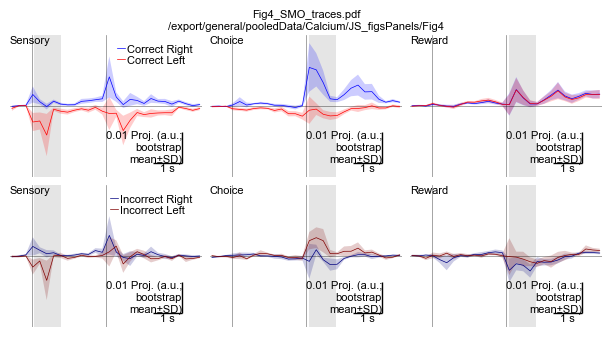

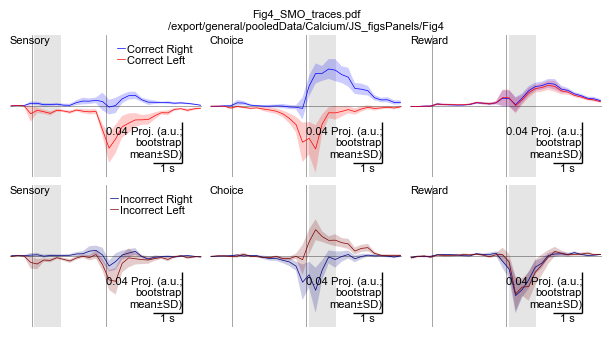

In [13]:

figName = 'Fig4_SMO_traces.pdf'
fontsize = 8
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\median±"+str(CI)+"% CI"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"
elif error == 'sem':
    errorLabel = "bootstrap\nmean±SEM"

projKey = 'pre'
lLabels = ['sensory', 'motor', 'outcome']
aColors = ['c', 'm', 'y']

aColors = [(0,0.75,0.75),(0.75,0,0.75)]
tColors = [(0,0,1),(1,0,0)]
linewidth = .5

axLabels = ['Sensory', 'Choice', 'Reward']
niceAnatLabels = ['Dendrites', 'Somas']

plotWindows = True
wColors = [(0,0,0),(0,0,0),(0,0,0)]
windows = np.vstack([[1.2,2.1],
                  [3.7,4.6]])

#S: 2:4 (-2.9 sec to -1.9 sec)
#M: 8:10 (0 sec to 1 sec)
#O: 10:12 (1 sec to 2 sec)
ylims = [[-0.023,0.023],[-0.07,0.07]] #by anat
xlim = [-3.2,3.2]
xticks = np.arange(7)-3

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.3
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.1
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True
vertLabel = 'Proj. (a.u.;\n'+errorLabel+')'
xticks = np.arange(7)-3

labels = ['Correct Right', 'Correct Left', 'Incorrect Right', 'Incorrect Left']
colors = [(0,0,1),(1,0,0), (0,0,0.5),(0.5,0,0)]
axLabels = ['Sensory', 'Choice', 'Reward']
modLabels = ['Go', 'Contact', 'Last Lick']
niceAnatLabels = ['Dendrites', 'Somas']
psWindow = [-3.6,3.6]
mod = 'GO'
if mod == 'GO':
    alignTime = 'Go Cue'
elif mod == 'CT':
    alignTime = 'Contact'
else:
    alignTime = 'Last Lick'
if alignTime == 'Go Cue':
    markers = [0,-1.25, -2.45]
    markers = [0, -2.45]
else:
    markers = [0]

markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5
alphas = [0.8,0.8,0.8]
alphas = [1,1,1]
figsize=(6,3)
nRows = 2
nCols = 

def maybe_pdf(save, path):
    return PdfPages(path) if save else nullcontext()
with maybe_pdf(PDF_export_active, os.path.join(figSaveDir, figName)) as pdf:
    for ak, anat in enumerate(anatKeys):
        fr = frs[ak]
        factor = factors[ak]
        F = fr/factor
    
        fig,axs=sled_general_tools.clean_subplots(nRows,nCols,figsize=figsize,facecolor='none',tight_layout = True, sharey = True)
    
        allData = SMO[anat]['pre'][mod] #boot, ttype, time, axis
        
        nTime = allData['projs']['pre'].shape[2]
        
        midPt = int(np.abs(psWindow[0])*F)
        tStart = int(F)
    
        x = np.linspace(psWindow[0], psWindow[1], nTime)
        plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
        lLabels = ['sensory', 'motor', 'outcome']
        aColors = ['c', 'm', 'y']
    
        linestyles = ['-','-','-']
        for a1, ax_ in enumerate(axs):
            for a2, ax in enumerate(ax_):
                ylim = ylims[ak]
                if plotWindows:
                    for w, win in enumerate(windows):
                        if a2==w and a2!=3:
                            ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
                        elif a2==2 and w==1:
                            ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
                for mark in markers:
                    ax.axvline(mark, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
                ax.axhline(0, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
        
        for t in range(4):
            for a in range(3):
                if t>1:
                    ax = axs[1,a]
                else:
                    ax = axs[0,a]
                for p, projKey in enumerate(['pre']):
                    color = colors[t]
                    data = copy.deepcopy(allData['projs'][projKey])
                    mean = np.nanmean(data[:,t,:,a],axis = 0)
                    med = np.nanmedian(data[:,t,:,a],axis = 0)
                    std = np.nanstd(data[:,t,:,a],axis = 0, ddof = 1)
                    sem = std / np.sqrt(data[:,t,:,a].shape[0])
                    low,high = np.nanpercentile(data[:,t,:,a],[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
                    if error == 'CI':
                        mainPlot  = med
                        errorLow = low
                        errorHigh = high
                    elif error == 'sem':
                        mainPlot  = mean
                        errorLow = mean-sem
                        errorHigh = mean+sem
                    elif error == 'std':
                        mainPlot  = mean
                        errorLow = mean-std
                        errorHigh = mean+std
                    
                    ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = color, alpha = 0.2, edgecolor='none')
                    ax.plot(x[plotIdx], mainPlot[plotIdx], color = color, alpha = alphas[p], linewidth=linewidth,linestyle = linestyles[p], label = labels[t])
                    
        for a1, ax_ in enumerate(axs):
            for a2, ax in enumerate(ax_):
                ylim = ylims[ak]
                ax.set_xlim(xlim)
                ax.set_ylim(ylim)
                if a2 == 0:
                    ax.legend(loc = 'upper right',frameon=False,fontsize=fontsize,handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3)
                ax.set_xticks(xticks)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.spines[['top','right','left','bottom']].set_visible(False)
                ax.text(xlim[0],ylim[1],axLabels[a2], fontsize = fontsize,ha='left',va='top')
                ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
            
        if PDF_export_active:
            pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
        sled_general_tools.display_clean_subplots(fig,ax)

In [14]:
#S: 2:4 (-2.9 sec to -1.9 sec)
#M: 8:10 (0 sec to 1 sec)
#O: 10:12 (1 sec to 2 sec)

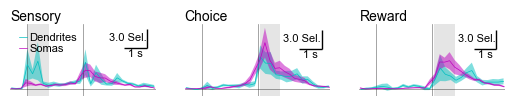

In [14]:

figName = 'Fig4_SMO_selectivity_traces.pdf'
fontsize = 8
figsize=(5.5,.8)
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.2,
    hspace=0.25
)

CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "bootstrap\nmedian±"+str(CI)+"% CI"
elif error == 'std':
    errorLabel = "bootstrap\nmean±SD"

projKey = 'pre'
lLabels = ['sensory', 'motor', 'outcome']
aColors = ['c', 'm', 'y']

aColors = [(0,0.75,0.75),(0.75,0,0.75)]
tColors = [(0,0,1),(1,0,0)]
linewidth = .5

#win2 = np.hstack([3.2,4])
# win2 = np.hstack([3.6,3.75])
# win1 = np.hstack([1.2,1.7])
axLabels = ['Sensory', 'Choice', 'Reward']
niceAnatLabels = ['Dendrites', 'Somas']
ylim = [-1.1,10]
xlim = [-3.2,3.2]
xticks = np.arange(7)-3

plot_scaleBar={}
plot_scaleBar['corner']='BR'
plot_scaleBar['length_s'] = 1
plot_scaleBar['height_per'] = 0.3
plot_scaleBar['lw'] = 1
plot_scaleBar['vertAdjust']=0.65
plot_scaleBar['horzAdjust']=0.1
plot_scaleBar['fontsize'] = fontsize
plot_scaleBar['includeLabel'] = True
vertLabel = 'Sel. (a.u.;\n'+errorLabel+')'
vertLabel = 'Sel. (a.u)'
vertLabel = 'Sel.'


if alignTime == 'Go Cue':
    markers = [0,-1.25, -2.45]
    markers = [0, -2.45]
else:
    markers = [0]
mod = 'GO'
markerLS = '-'
markerLW = 0.5
markerColor = (0,0,0)
markerAlpha = 0.5

plotWindows = True
wColors = [(0,0,0),(0,0,0)]
windows = np.vstack([[1.2,2.1],
                  [3.7,4.6]])

fig,axs=sled_general_tools.clean_subplots(1,3,figsize=figsize,facecolor='none',tight_layout = False, sharey = True, gridspec_kw=gridspec_kw)
for a, ax in enumerate(axs[0,:]):
    for mark in markers:
        ax.plot([mark]*10, np.linspace(ylim[0], ylim[1], 10), lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    ax.plot(np.linspace(xlim[0], xlim[1], 10), [0]*10, lw = markerLW, color = markerColor, linestyle = markerLS, alpha = markerAlpha)
    if plotWindows:
        for w, win in enumerate(windows):
            if a==w and a!=3:
                ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
            elif a==2 and w==1:
                ax.fill_between(win-3.6,[ylim[0]]*2, [ylim[1]]*2, color = wColors[w], alpha = 0.1,edgecolor='none')
    ax.text(xlim[0],ylim[1],axLabels[a],ha='left',va='bottom',fontsize=fontsize+2)

for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    x = np.linspace(psWindow[0], psWindow[1], data.shape[2])
    plotIdx = np.arange(np.argmin(np.absolute(x-xlim[0])),np.argmin(np.absolute(x-xlim[1]))+1)
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
        
    allSels = np.dstack(allSels) #boot, time, axis
    denom = np.nanmean(allSels)
    normed = allSels/denom
    
    for a in range(3):
        ax = axs[0,a]
        dif = normed[:,:,a]
        
        mean = np.nanmean(dif,axis = 0)
        med = np.nanmedian(dif,axis = 0)
        std = np.nanstd(dif,axis = 0, ddof = 1)
        sem = std / np.sqrt(dif.shape[0])
        low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))], axis = 0)
        if error == 'CI':
            mainPlot  = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot  = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot  = mean
            errorLow = mean-std
            errorHigh = mean+std

        ax.fill_between(x[plotIdx], errorLow[plotIdx], errorHigh[plotIdx], color = aColors[ak], alpha = 0.5,edgecolor='none')
        ax.plot(x[plotIdx], mainPlot[plotIdx], color = aColors[ak], linewidth=linewidth, label = niceAnatLabels[ak])
        
for a, ax in enumerate(axs[0,:]):
    ax,plot_scaleBar = sled_ROI_tools.add_plot_scaleBar(ax,plot_scaleBar,(0,0,0),True,vertLabel)
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_ylim(ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top','right','left','bottom']].set_visible(False)
    # ax.tick_params(axis='both', which='major', labelsize=fontsize-4) #
    if a == 0:
        ax.legend(frameon=False,fontsize=fontsize,loc='upper left',handlelength=0.75, markerscale=0.75, handletextpad=0.2, labelspacing=0.1,  borderpad=0.3) 

if mod == 'GO':
    alignTime = 'Go Cue'
elif mod == 'CT':
    alignTime = 'Contact'
else:
    alignTime = 'Last Lick'
        
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)

dendrites Sensory/Choice mean: 0.845 std: 0.556 pval: 0.543
somas Sensory/Choice mean: 0.172 std: 0.071 pval: 0.000
Sensory/Choice pVal = 0.016

dendrites Sensory/Reward mean: 1.560 std: 1.132 pval: 0.702
somas Sensory/Reward mean: 0.281 std: 0.096 pval: 0.000
Sensory/Reward pVal = 0.013


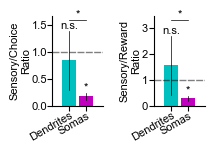

In [15]:
figName = 'Fig4_SMO_ratios.pdf'
fontsize = 8

colors = ['b', 'r', 'darkblue', 'darkred']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
lLabels = ['sensory', 'motor', 'outcome']
# aColors = ['c', 'm', 'y']
mod = 'GO'
projKey = 'pre'
fontsize = 8
alpha = 0.01
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boostrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "bootstrap mean±SEM"
elif error == 'std':
    errorLabel = "bootstrap mean±SD"

linewidth = .5
#win2 = np.hstack([3.2,4])
win2 = np.hstack([3.6,3.75])
win1 = np.hstack([1.2,1.7])
niceAnatLabels = ['Dendrites', 'Somas']
ylims=[[0.5,3.5],[0.7,2.4]]
testLS = ':'
testDashes = (5,1)
testLW = 1
testColor = (0,0,0)
testAlpha = 0.5
xlim=(-1, 2)

figsize = [1.7,1]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=1,
    hspace=0.0
)

fig,axs=sled_general_tools.clean_subplots(1,2,figsize=figsize,facecolor='none', sharey = False,sharex=True, gridspec_kw=gridspec_kw)


ax = axs[0,0]
testLine = 1
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)
windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
allSels2 = {}

for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = allSels.sum(axis=(1,2))
    normed = allSels/denom[:,None,None]

    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)

    ############################## this is the actual statistic ##############################
    dif = sensAvged/moAvged
    title = 'Sensory/Choice'
    ##############################
    
    allSels2[anat] = dif

    mean = np.nanmean(dif)
    med = np.nanmedian(dif)
    std = np.nanstd(dif, ddof = 1)
    sem = std / np.sqrt(dif.shape[0])
    low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
    if error == 'CI':
        mainPlot = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot = mean
        errorLow = mean-std
        errorHigh = mean+std
    ax.bar(ak, mainPlot, color = aColors[ak], alpha = 1,width=0.85)
    ax.plot([ak]*2,[errorLow,errorHigh], color = (0,0,0),lw = linewidth)

    tail1 = np.sum(dif<testLine)/data.shape[0]
    tail2 = np.sum(dif>testLine)/data.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    # print(f'{title} {anat} pVal = {pVal:.6f}')
    print(anat, title, f'mean: {np.nanmean(dif):.03f}', f'std: {np.nanstd(dif):.03f}', f'pval: {pVal:.03f}')
    pText = sled_stat_tools.pstar(pVal,inclP = False)
    ax.text(ak,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')

ax.set_xlim(xlim)
ax.set_xticks([0,1])
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')

pVal = np.sum(allSels2['somas']>allSels2['dendrites'])/allSels2['somas'].shape[0]
pText = sled_stat_tools.pstar(pVal,inclP = False)
print(f'{title} pVal = {pVal:.3f}')
compAnatLine = 1.6
ax.text(.5,compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
ax.plot([0,1], [compAnatLine]*2, color = (0,0,0),linewidth=linewidth)
ax.spines[['top','right']].set_visible(False)
# ax.set_ylabel(title+" Ratio\n("+str(errorLabel)+")",fontsize=fontsize)
ax.set_ylabel(title+"\nRatio",fontsize=fontsize,labelpad=0)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
ylim = ax.get_ylim()
print('')

###################################################################################
ax = axs[0,1]
testLine = 1
ax.axhline(testLine, lw = testLW, color = testColor, linestyle = testLS, alpha = testAlpha, dashes=testDashes)

windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
allSels2 = {}
for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = np.nanmean(allSels)
    normed = allSels/denom

    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)#+offset
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)#offset
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)#+offset

    ############################## this is the actual statistic ##############################
    # dif = moAvged/sensAvged
    dif = sensAvged/oAvged
    title = 'Sensory/Reward'
    ##############################
    
    allSels2[anat] = dif

    mean = np.nanmean(dif)
    med = np.nanmedian(dif)
    std = np.nanstd(dif, ddof = 1)
    sem = std / np.sqrt(dif.shape[0])
    low,high = np.nanpercentile(dif,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
    if error == 'CI':
        mainPlot  = med
        errorLow = low
        errorHigh = high
    elif error == 'sem':
        mainPlot  = mean
        errorLow = mean-sem
        errorHigh = mean+sem
    elif error == 'std':
        mainPlot  = mean
        errorLow = mean-std
        errorHigh = mean+std    
    ax.bar(ak, mainPlot, color = aColors[ak], alpha = 1,width = 0.85)
    ax.plot([ak]*2,[errorLow, errorHigh], color = (0,0,0),lw = linewidth)

    tail1 = np.sum(dif<testLine)/data.shape[0]
    tail2 = np.sum(dif>testLine)/data.shape[0]
    twoTails = 2 * min(tail1, tail2)
    pVal = min(twoTails, 1.0)
    pText = sled_stat_tools.pstar(pVal,inclP = False)

    print(anat, title, f'mean: {np.nanmean(dif):.03f}', f'std: {np.nanstd(dif):.03f}', f'pval: {pVal:.03f}')
    ax.text(ak,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')
    #print('')
ax.set_xlim(xlim)
ax.set_xticks([0,1])
ax.set_ylabel(title+"\nRatio",fontsize=fontsize,labelpad=0)
ax.set_xticklabels(niceAnatLabels,fontsize=fontsize,rotation=30,ha='right',va='top',rotation_mode='anchor')

pVal = np.sum(allSels2['somas']>allSels2['dendrites'])/allSels2['somas'].shape[0]
pText = sled_stat_tools.pstar(pVal,inclP = False)
print(f'{title} pVal = {pVal:.3f}')# {allSels2["dendrites"].shape[0]}')
compAnatLine = 3.3
ax.text(.5,compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
ax.plot([0,1], [compAnatLine]*2, color = (0,0,0),linewidth=linewidth)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 1) #
ylim = ax.get_ylim()
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
    sled_general_tools.display_clean_subplots(fig,ax)

dendrites Sensory mean: 0.029 std: 0.013 pval: 0.000
dendrites Choice mean: 0.039 std: 0.010 pval: 0.000
dendrites Reward mean: 0.023 std: 0.008 pval: 0.000

somas Sensory mean: 0.008 std: 0.003 pval: 0.000
somas Choice mean: 0.046 std: 0.008 pval: 0.000
somas Reward mean: 0.027 std: 0.005 pval: 0.000

Sensory pVal = 0.015000
Choice pVal = 0.709700
Reward pVal = 0.687900


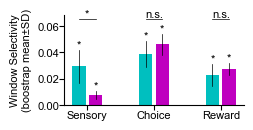

In [16]:
figName = 'Fig4_SMO_bar.pdf'
fontsize = 8
mod = 'GO'
projKey = 'pre'
linewidth = 0.5
SMO_labels = ['Sensory','Choice','Reward']
lLabels = ['sensory', 'motor', 'outcome']
aColors = [(0,0.75,0.75),(0.75,0,0.75)]
niceAnatLabels = ['Dendrites', 'Somas']
allSels2 = {}

windows = np.vstack([[1.2,2.1],
                        [3.7,4.6]])
CI = 68
error = 'std'
if error == 'CI':
    errorLabel = "boostrap median±"+str(CI)+"% CI"
elif error == 'sem':
    errorLabel = "boostrap mean±SEM"
elif error == 'std':
    errorLabel = "boostrap mean±SD"

figsize = [2,1]
gridspec_kw=dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.5,
    hspace=0.0
)

fig,axs=sled_general_tools.clean_subplots(1,1,figsize=figsize,facecolor='none', sharey = False,sharex=False, gridspec_kw=gridspec_kw)
ax = axs[0,0]
for ak, anat in enumerate(anatKeys):
    fr = frs[ak]
    factor = factors[ak]
    F = fr/factor

    allData = SMO[anat]['pre'][mod]
    s2 = [1,-1,1,-1] #CR, CL, FR, FL
    m2 = [1,-1,-1,1]
    o2 = [1,1,-1,-1]
    y2 = np.vstack([s2,m2,o2])
    
    nTime = allData['projs']['pre'].shape[2]

    x = np.linspace(-3.6,3.6, nTime)
    aColors = ['c', 'm', 'y']
    
    data = allData['projs'][projKey] #boot, trial, time, axis
    allSels = []
    for a in range(3):
        axData = data[:,:,:,a]
        grp1 = np.nanmean(axData[:,y2[a]==1,:],axis = 1)
        grp2 = np.nanmean(axData[:,y2[a]==-1,:],axis = 1)
        dif = grp1-grp2
        allSels.append(dif)
    
    allSels = np.dstack(allSels)
    denom = allSels.sum(axis=(1,2))
    normed = allSels/denom[:,None,None]

    sensAvged = np.nanmean(normed[:,int(windows[0][0]*F):int(windows[0][1]*F),0], axis = 1)
    moAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),1], axis = 1)
    oAvged = np.nanmean(normed[:,int(windows[1][0]*F):int(windows[1][1]*F),2], axis = 1)

    data2plot  = [sensAvged, moAvged, oAvged]
    allSels2[anat] = {}
    for d, data in enumerate(data2plot):
        mean = np.nanmean(data)
        med = np.nanmedian(data)
        std = np.nanstd(data, ddof = 1)
        sem = std / np.sqrt(data.shape[0])
        low,high = np.nanpercentile(data,[100-(CI+((100-CI)/2)),(CI+((100-CI)/2))])
        if error == 'CI':
            mainPlot  = med
            errorLow = low
            errorHigh = high
        elif error == 'sem':
            mainPlot  = mean
            errorLow = mean-sem
            errorHigh = mean+sem
        elif error == 'std':
            mainPlot  = mean
            errorLow = mean-std
            errorHigh = mean+std    
        x = d+(ak*.25)
        ax.bar(x, mainPlot, color = aColors[ak], alpha = 1, width = 0.2)
        ax.plot([x]*2, [errorLow,errorHigh], color = (0,0,0),lw = linewidth)

        testLine = 0
        tail1 = np.sum(data<testLine)/data.shape[0]
        tail2 = np.sum(data>testLine)/data.shape[0]
        twoTails = 2 * min(tail1, tail2)
        pVal = min(twoTails, 1.0)
        pText = sled_stat_tools.pstar(pVal,inclP = False)
        # print(f'{anat} {SMO_labels[d]} pVal: {pVal:.3f}')
        print(anat, SMO_labels[d], f'mean: {np.nanmean(data):.03f}', 
                f'std: {np.nanstd(data):.03f}', f'pval: {pVal:.03f}')
        ax.text(x,errorHigh,pText,fontsize=fontsize,ha='center',va='bottom')
        allSels2[anat][SMO_labels[d]] = data
    print('')
    
compAnatLine = .065

for s, smoLabel in enumerate(SMO_labels):
    x = [s,s+.25]
    pVal = np.sum(allSels2['somas'][smoLabel]>allSels2['dendrites'][smoLabel])/allSels2['somas'][smoLabel].shape[0]
    pText = sled_stat_tools.pstar(pVal,inclP = False)
    print(f'{smoLabel} pVal = {pVal:.6f}')
    ax.text(np.nanmean(x),compAnatLine,pText,fontsize=fontsize,ha='center',va='bottom')
    ax.plot(x, [compAnatLine]*2, color = (0,0,0),lw=linewidth)
    ax.spines[['top','right']].set_visible(False)

ax.set_xticks(np.arange(3)+.125)
DorS = 'D    S'
xlabels = []
for i in range(3):
    xlabels.append(f'{SMO_labels[i]}')
ax.set_xticklabels(xlabels,fontsize=fontsize)
ax.set_ylabel('Window Selectivity\n('+errorLabel+')',fontsize=fontsize)
ax.tick_params(axis='x', which='major', labelsize=fontsize,pad= 0) #
ax.tick_params(axis='y', which='major', labelsize=fontsize,pad= 0) #
if PDF_export_active:
    with PdfPages(os.path.join(figSaveDir,figName)) as pdf:
        pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
sled_general_tools.display_clean_subplots(fig,ax)